In [ ]:
import zipfile
import os

# Sesuaikan dengan nama file di panel kiri: 'flower.zip'
zip_file_path = 'flower.zip'
extract_dir = 'dataset_flowers'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Ekstraksi selesai!")

Ekstraksi selesai!


In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# GANTI DENGAN NIM KAMU DI SINI (Contoh: 12345678)
NIM = 12345678
# ==========================================

print(f"Random State yang digunakan (NIM): {NIM}")

Random State yang digunakan (NIM): 12345678


In [7]:
dataset_dir = 'dataset_flowers'

# Cari folder utama di dalam dataset_flowers
subfolders = os.listdir(dataset_dir)
if len(subfolders) == 1 and os.path.isdir(os.path.join(dataset_dir, subfolders[0])):
    base_path = os.path.join(dataset_dir, subfolders[0])
else:
    base_path = dataset_dir

# Deteksi nama-nama kelas (folder bunga)
categories = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
categories.sort()

print("Kelas yang ditemukan:", categories)

X = []
y = []
IMG_SIZE = 64  # Ukuran gambar 64x64 piksel

for label, category in enumerate(categories):
    folder_path = os.path.join(base_path, category)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        # BACA gambar & konversi warna ke RGB
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)

X = np.array(X)
y = np.array(y)

print(f"Total gambar berhasil dimuat: {len(X)}")

# Normalisasi piksel ke skala 0 - 1 & Flatten gambar untuk MLP
X_flatten = X.reshape(len(X), -1) / 255.0

Kelas yang ditemukan: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total gambar berhasil dimuat: 4317


In [9]:
# Pembagian Data 80:20 menggunakan NIM sebagai random_state
X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X_flatten, y, X, test_size=0.20, random_state=NIM, stratify=y
)

print(f"Jumlah Data Training: {len(X_train)}")
print(f"Jumlah Data Testing: {len(X_test)}")

# Membuat & Melatih Model MLP
print("\nSedang melatih model MLP, mohon tunggu sebentar...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=150,
    random_state=NIM,
    verbose=True
)

mlp_model.fit(X_train, y_train)
print("Pelatihan Selesai!")

Jumlah Data Training: 3453
Jumlah Data Testing: 864

Sedang melatih model MLP, mohon tunggu sebentar...
Iteration 1, loss = 2.67917593
Iteration 2, loss = 1.52728738
Iteration 3, loss = 1.35921173
Iteration 4, loss = 1.29731791
Iteration 5, loss = 1.25870209
Iteration 6, loss = 1.22501673
Iteration 7, loss = 1.22157465
Iteration 8, loss = 1.16588188
Iteration 9, loss = 1.22504171
Iteration 10, loss = 1.13191444
Iteration 11, loss = 1.11654977
Iteration 12, loss = 1.15219821
Iteration 13, loss = 1.07769235
Iteration 14, loss = 1.05892229
Iteration 15, loss = 1.05692254
Iteration 16, loss = 1.03102241
Iteration 17, loss = 0.98482413
Iteration 18, loss = 0.97807335
Iteration 19, loss = 0.95067692
Iteration 20, loss = 0.95690868
Iteration 21, loss = 0.93222415
Iteration 22, loss = 0.90554623
Iteration 23, loss = 0.89901613
Iteration 24, loss = 0.86990368
Iteration 25, loss = 0.86187584
Iteration 26, loss = 0.87018196
Iteration 27, loss = 0.79023961
Iteration 28, loss = 0.80604642
Iteration


     HASIL METRIK EVALUASI MODEL     
Accuracy  : 45.37%
Precision : 46.29%
Recall    : 45.37%
F1-Score  : 45.15%

Laporan Klasifikasi Lengkap:
              precision    recall  f1-score   support

       daisy       0.47      0.29      0.36       153
   dandelion       0.45      0.53      0.49       210
        rose       0.41      0.52      0.46       157
   sunflower       0.62      0.49      0.55       147
       tulip       0.40      0.41      0.40       197

    accuracy                           0.45       864
   macro avg       0.47      0.45      0.45       864
weighted avg       0.46      0.45      0.45       864



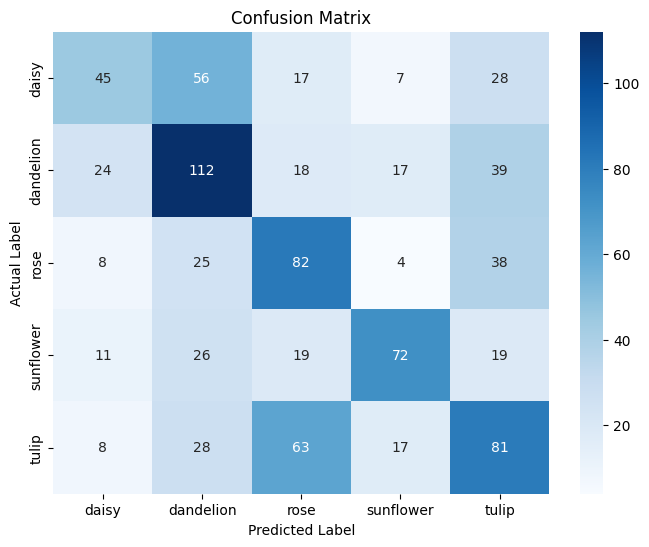

In [10]:
# Prediksi data testing
y_pred = mlp_model.predict(X_test)

# Hitung Metrik
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n" + "="*40)
print("     HASIL METRIK EVALUASI MODEL     ")
print("="*40)
print(f"Accuracy  : {acc * 100:.2f}%")
print(f"Precision : {prec * 100:.2f}%")
print(f"Recall    : {rec * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")
print("="*40)

# Laporan Detail per Kelas
print("\nLaporan Klasifikasi Lengkap:")
print(classification_report(y_test, y_pred, target_names=categories))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

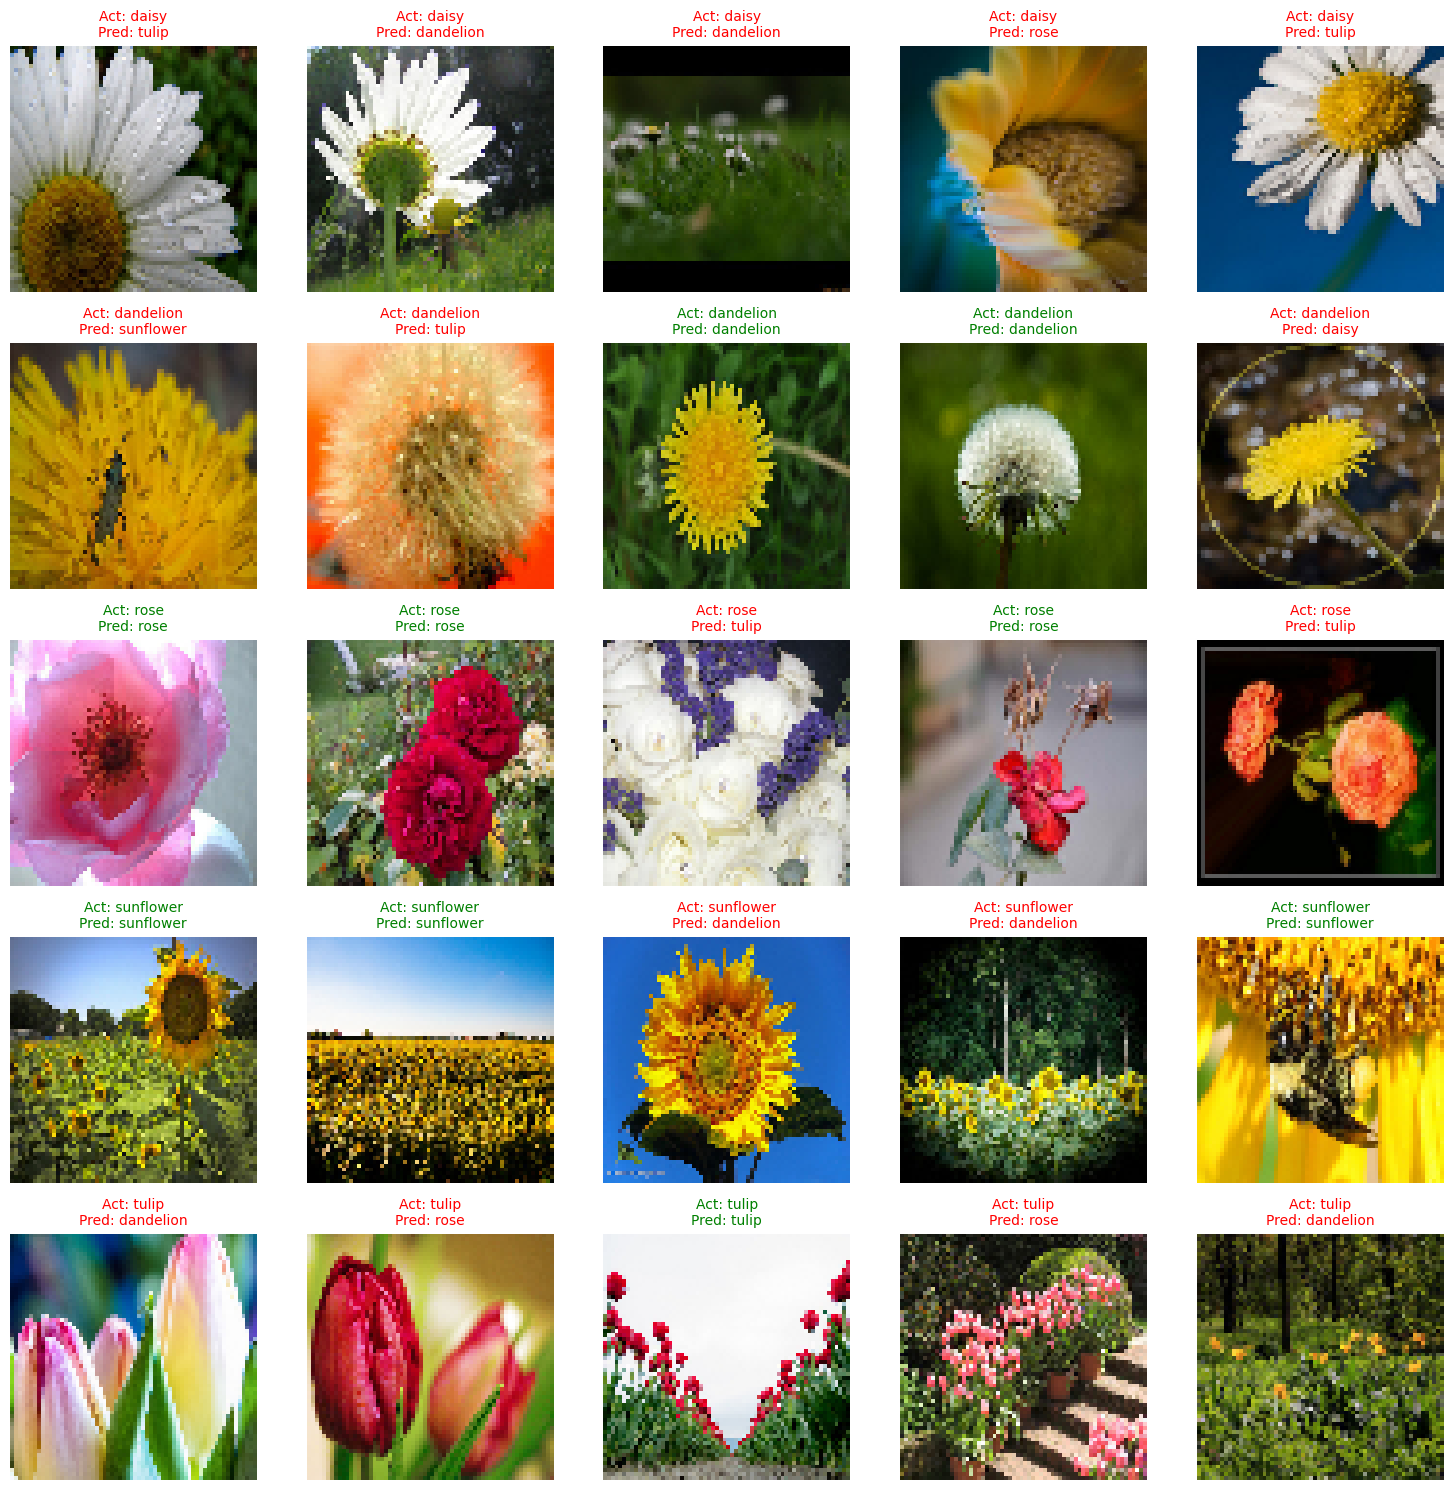

In [11]:
np.random.seed(NIM)

plt.figure(figsize=(15, 15))
plot_idx = 1

for class_idx, class_name in enumerate(categories):
    # Ambil indeks semua gambar yang termasuk dalam kelas ini di data testing
    indices = np.where(y_test == class_idx)[0]

    # Pilih 5 gambar secara acak
    selected_indices = np.random.choice(indices, size=5, replace=False)

    for idx in selected_indices:
        plt.subplot(5, 5, plot_idx)
        plt.imshow(img_test[idx])

        actual_label = categories[y_test[idx]]
        pred_label = categories[y_pred[idx]]

        # Warna hijau jika prediksi benar, merah jika salah
        color = 'green' if actual_label == pred_label else 'red'

        plt.title(f"Act: {actual_label}\nPred: {pred_label}", color=color, fontsize=10)
        plt.axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()